# Temporal Curvature on Math Task \n## Part 1: Llama-3.1-8B-Instruct — Turn 

In [49]:
import json
from pathlib import Path
import pandas as pd

FILES = [
    "logs/math/cot-sharded-at0-ut0/cot-sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl",
]

def count_turns(trace):
    # 统计 shard_revealed 事件总数：第 1 次 = goal 揭示，后续每次 = 新 hint/shard
    # 等于 .pt 文件中 ["goal", "turn_1", ..., "turn_N"] 的标签总数
    return sum(
        1 for event in trace
        if event.get("role") == "log"
        and isinstance(event.get("content"), dict)
        and event["content"].get("type") == "shard_revealed"
    )

def load_records(file_paths):
    rows = []
    for file_path in file_paths:
        with open(file_path) as f:
            for line in f:
                record = json.loads(line)
                rows.append({
                    "conv_id": record["conv_id"],
                    "task_id": record["task_id"],
                    "file": Path(file_path).name,
                    "turns": count_turns(record.get("trace", [])),
                    "score": record.get("score"),
                })
    return pd.DataFrame(rows)

df = load_records(FILES)
df["correct"] = df["score"].eq(1)
df["incorrect"] = df["score"].ne(1)  # 0 或缺失都算错误

In [50]:
def summarize_counts(frame, group_col):
    summary = frame.groupby(group_col)[["correct", "incorrect"]].sum().astype(int)
    summary["total"] = summary.sum(axis=1)
    summary["accuracy"] = summary["correct"] / summary["total"]
    return summary

summary = summarize_counts(df, "turns")[["correct", "incorrect", "total"]]
summary.index.name = "turns"


# turns = 1（goal 揭示）+ N（后续 hint/shard 轮次），与 .pt 的 total_turns 对齐
TARGET_TURNS = [3, 4, 5, 6, 7, 8]
target_summary = summary.loc[summary.index.isin(TARGET_TURNS)]

file_summary = summarize_counts(df, "file")
combined_summary = pd.DataFrame([
    {
        "file": "combined",
        "correct": int(df["correct"].sum()),
        "incorrect": int(df["incorrect"].sum()),
        "total": int(len(df)),
    }
])
combined_summary["accuracy"] = combined_summary["correct"] / combined_summary["total"]
combined_summary = combined_summary.set_index("file")

print("=== 每个文件统计 ===")
print(file_summary[["correct", "incorrect", "accuracy", "total"]].to_string(float_format=lambda x: f"{x:.4f}"))
print()
print("=== 两个文件合并统计 ===")
print(combined_summary[["correct", "incorrect", "accuracy", "total"]].to_string(float_format=lambda x: f"{x:.4f}"))
print()
print("=== 全部 turns ===")
print(summary.to_string())
print()
print("=== 目标 turns 3-8 ===")
print(target_summary.to_string())
print(f"\n目标 turns 3-8 总计: {target_summary['total'].sum()} 条")

=== 每个文件统计 ===
                                                                 correct  incorrect  accuracy  total
file                                                                                                
cot-sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl       33         70    0.3204    103

=== 两个文件合并统计 ===
          correct  incorrect  accuracy  total
file                                         
combined       33         70    0.3204    103

=== 全部 turns ===
       correct  incorrect  total
turns                           
3            1          0      1
4            8         14     22
5            8         22     30
6           10         15     25
7            1         13     14
8            4          5      9
9            0          1      1
11           1          0      1

=== 目标 turns 3-8 ===
       correct  incorrect  total
turns                           
3            1          0      1
4            8         14     22
5            8         2

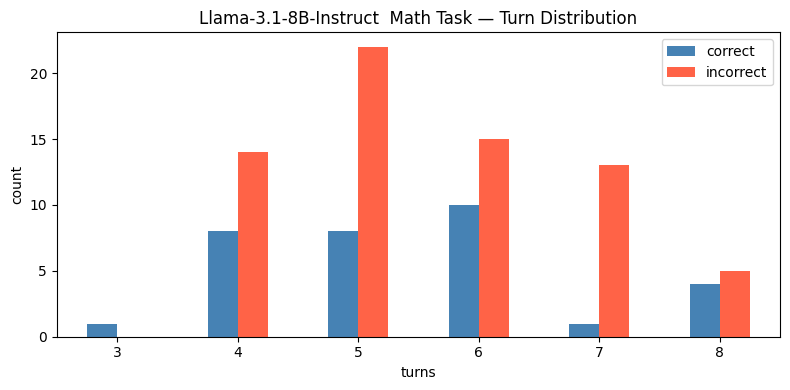

In [51]:
import matplotlib.pyplot as plt

target = summary.loc[summary.index.isin(TARGET_TURNS)]
fig, ax = plt.subplots(figsize=(8, 4))
target[["correct", "incorrect"]].plot(kind="bar", ax=ax, color=["steelblue", "tomato"])
ax.set_xlabel("turns")
ax.set_ylabel("count")
ax.set_title("Llama-3.1-8B-Instruct  Math Task — Turn Distribution")
ax.set_xticklabels(target.index, rotation=0)
plt.tight_layout()
plt.show()

## Temporal Curvature  κ = cos(Δhₜ, Δhₜ₋₁)

In [52]:
import torch
import numpy as np
from pathlib import Path

PT_DIRS = [
    "logs/hidden_states/math/cot-sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct",
]
FOCUS_LAYER = 3  # index into [12,16,20,24,28] → layer 20

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 1e-9 and nb > 1e-9 else np.nan

correct_map = dict(zip(df["conv_id"], df["correct"]))

rows_tc = []
for cid, is_correct in correct_map.items():
    pt_file_path = None
    for pt_dir in PT_DIRS:
        candidate = Path(pt_dir) / f"{cid}.pt"
        if candidate.exists():
            pt_file_path = candidate
            break
    if pt_file_path is None:
        print(f"Warning: pt file for conv_id {cid} not found in PT_DIRS, skipping.")
        continue
    data = torch.load(pt_file_path, map_location="cpu", weights_only=False)
    hs_map = {e["label"]: e["hidden_states"][FOCUS_LAYER].numpy()
              for e in data["hidden_states"]}
    turn_labels = sorted(
        [k for k in hs_map if k.startswith("turn_")],
        key=lambda x: int(x.split("_")[1])
    )
    # goal 视为 turn_0，拼到序列最前面
    # 使 turns（此处 = len(all_labels)）与 JSONL count_turns() 的计数对齐
    # kappa 时间序列因此从 turn_idx=2 开始（用 goal→turn_1→turn_2 三点计算）
    all_labels = ["goal"] + turn_labels
    turns = len(all_labels)  # 1（goal）+ N（turn_1..turn_N）

    for i in range(2, turns):  # 需要连续三个点才能算 kappa
        tl, tp1, tp2 = all_labels[i], all_labels[i-1], all_labels[i-2]
        kappa = cosine(hs_map[tl] - hs_map[tp1], hs_map[tp1] - hs_map[tp2])
        rows_tc.append({
            "conv_id": cid,
            "turns": turns,        # 总标签数，等于 df["turns"]
            "turn_idx": int(tl.split("_")[1]),  # 当前 kappa 对应的 turn 编号
            "kappa": kappa,
            "correct": bool(is_correct),
        })

df_tc = pd.DataFrame(rows_tc)
print(len(df_tc), "turn comparisons loaded.")
df_tc.head()

375 turn comparisons loaded.


,conv_id,turns,turn_idx,kappa,correct
0,6a1e06904067d32a46a6e173,6,2,-0.427135,False
1,6a1e06904067d32a46a6e173,6,3,-0.351493,False
2,6a1e06904067d32a46a6e173,6,4,-0.203143,False
3,6a1e06904067d32a46a6e173,6,5,-0.315821,False
4,6a1e06a84067d32a46a6e174,6,2,-0.094737,False


In [53]:
from scipy import stats as scipy_stats

target_tc = df_tc[df_tc["turns"].isin(TARGET_TURNS)]

rows_overall = []
for turn_idx, grp in target_tc.groupby("turn_idx"):
    for label, is_correct in [("correct", True), ("incorrect", False)]:
        vals = grp[grp["correct"] == is_correct]["kappa"].dropna().values
        if len(vals) == 0:
            continue
        mean = vals.mean()
        se = scipy_stats.sem(vals)
        ci = se * scipy_stats.t.ppf(0.9, df=len(vals)-1)  # 90% CI
        rows_overall.append({"turn_idx": turn_idx, "label": label,
                              "mean": mean, "ci": ci, "n": len(vals)})

df_overall = pd.DataFrame(rows_overall)
print(df_overall.pivot(index="turn_idx", columns="label", values=["mean", "ci", "n"]).round(4))

            mean                ci                 n          
label    correct incorrect correct incorrect correct incorrect
turn_idx                                                      
2        -0.2273   -0.2245  0.0228    0.0196    32.0      69.0
3         0.0851    0.0381  0.0252    0.0188    31.0      69.0
4        -0.2251   -0.1615  0.0663    0.0436    23.0      55.0
5        -0.2630   -0.3389  0.1117    0.0624    15.0      33.0
6        -0.1728   -0.2677  0.2230    0.0763     5.0      18.0
7        -0.5228   -0.1605  0.0590    0.1950     4.0       5.0


In [54]:
from scipy import stats as scipy_stats

# 失败类别标签与 colors，供后面的 AUROC 图复用
def classify_entry_math(rec):
    score = rec.get("score")
    if score not in (0, 0.0, None):
        return "SUCCESS"
    trace = rec.get("trace", [])
    verifications, evals = [], []
    for msg in trace:
        c = msg.get("content", {})
        if msg.get("role") != "log" or not isinstance(c, dict):
            continue
        t = c.get("type", "")
        if t == "system-verification":
            verifications.append(c.get("response", {}))
        elif t == "answer-evaluation":
            evals.append(c)
    if score is None:
        return "NEVER_ATTEMPTED_ANSWER"
    if not verifications or not evals:
        return "ATTEMPTED_BUT_UNRESOLVED"
    if verifications[-1].get("response_type") == "refuse":
        return "REFUSES_TO_ANSWER"
    if verifications[-1].get("response_type") in ("discussion", "clarification", "interrogation"):
        return "ATTEMPTED_BUT_UNRESOLVED"
    answers = list(dict.fromkeys(e.get("exact_answer", "") for e in evals))
    return "SAME_WRONG_DESPITE_HINTS" if len(answers) == 1 else "EVOLVES_STAYS_WRONG"

cat_map = {}
for fpath in FILES:
    with open(fpath) as f:
        for line in f:
            rec = json.loads(line)
            cat_map[rec["conv_id"]] = classify_entry_math(rec)

df_tc["category"] = df_tc["conv_id"].map(cat_map)

COLORS = {
    "SUCCESS":                  "steelblue",
    "SAME_WRONG_DESPITE_HINTS": "#ef4444",
    "EVOLVES_STAYS_WRONG":      "#f97316",
    "ATTEMPTED_BUT_UNRESOLVED": "#eab308",
    "NEVER_ATTEMPTED_ANSWER":   "#a78bfa",
    "REFUSES_TO_ANSWER":        "#8b5cf6",
}

# 各 turns 的类别分布（turns = 1 goal + N exchanges，与 df["turns"] 一致）
cat_counts = (
    pd.DataFrame(cat_map.items(), columns=["conv_id", "category"])
    .merge(df_tc[["conv_id", "turns"]].drop_duplicates(), on="conv_id")
    .query("turns in @TARGET_TURNS")
    .groupby(["turns", "category"])
    .size()
    .unstack(fill_value=0)
)
print("=== 各 turns 的失败类别分布 ===")
print(cat_counts.to_string())

=== 各 turns 的失败类别分布 ===
category  ATTEMPTED_BUT_UNRESOLVED  EVOLVES_STAYS_WRONG  NEVER_ATTEMPTED_ANSWER  SAME_WRONG_DESPITE_HINTS  SUCCESS
turns                                                                                                             
3                                0                    0                       0                         0        1
4                                0                    0                      11                         3        8
5                                0                    1                      18                         3        8
6                                0                    1                       9                         5       10
7                                1                    2                       4                         6        1
8                                0                    1                       1                         3        4


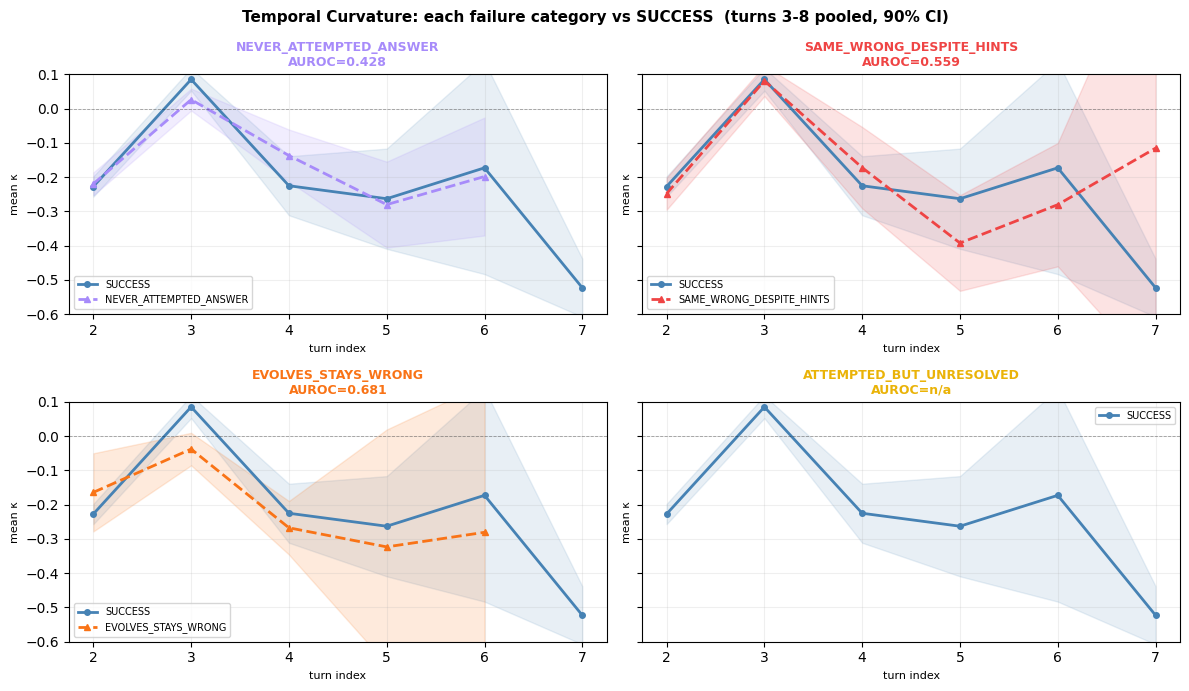

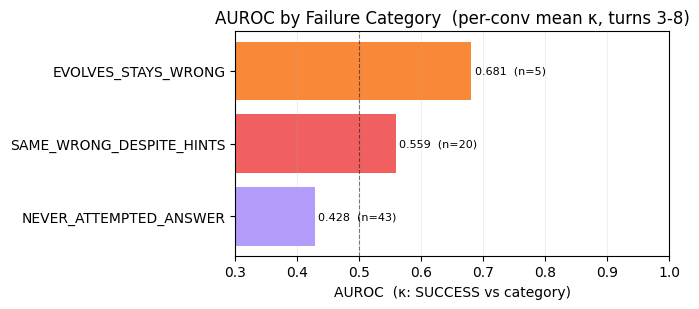

In [55]:
import json
from scipy import stats as scipy_stats

from sklearn.metrics import roc_auc_score

def classify_entry_math(rec):
    score = rec.get("score")
    if score not in (0, 0.0, None):
        return "SUCCESS"
    trace = rec.get("trace", [])
    verifications, evals = [], []
    for msg in trace:
        c = msg.get("content", {})
        if msg.get("role") != "log" or not isinstance(c, dict):
            continue
        t = c.get("type", "")
        if t == "system-verification":
            verifications.append(c.get("response", {}))
        elif t == "answer-evaluation":
            evals.append(c)
    if score is None:
        return "NEVER_ATTEMPTED_ANSWER"
    if not verifications or not evals:
        return "ATTEMPTED_BUT_UNRESOLVED"
    if verifications[-1].get("response_type") == "refuse":
        return "REFUSES_TO_ANSWER"
    if verifications[-1].get("response_type") in ("discussion", "clarification", "interrogation"):
        return "ATTEMPTED_BUT_UNRESOLVED"
    answers = list(dict.fromkeys(e.get("exact_answer", "") for e in evals))
    return "SAME_WRONG_DESPITE_HINTS" if len(answers) == 1 else "EVOLVES_STAYS_WRONG"

cat_map = {}
for fpath in FILES:
    with open(fpath) as f:
        for line in f:
            rec = json.loads(line)
            cat_map[rec["conv_id"]] = classify_entry_math(rec)

df_tc["category"] = df_tc["conv_id"].map(cat_map)

COLORS = {
    "SUCCESS":                  "steelblue",
    "SAME_WRONG_DESPITE_HINTS": "#ef4444",
    "EVOLVES_STAYS_WRONG":      "#f97316",
    "ATTEMPTED_BUT_UNRESOLVED": "#eab308",
    "NEVER_ATTEMPTED_ANSWER":   "#a78bfa",
    "REFUSES_TO_ANSWER":        "#8b5cf6",
}

target_tc2 = df_tc[df_tc["turns"].isin(TARGET_TURNS)].copy()

ERROR_CATS = [
    "NEVER_ATTEMPTED_ANSWER",
    "SAME_WRONG_DESPITE_HINTS",
    "EVOLVES_STAYS_WRONG",
    "ATTEMPTED_BUT_UNRESOLVED",
]

def cat_turn_curve(df, cat):
    rows = []
    for ti, g in df[df["category"] == cat].groupby("turn_idx"):
        vals = g["kappa"].dropna().values
        if len(vals) < 3:
            continue
        mean = vals.mean()
        ci = scipy_stats.sem(vals) * scipy_stats.t.ppf(0.95, df=len(vals)-1)
        rows.append({"turn_idx": ti, "mean": mean, "ci": ci})
    return pd.DataFrame(rows).sort_values("turn_idx") if rows else pd.DataFrame()

success_curve = cat_turn_curve(target_tc2, "SUCCESS")
success_conv_kappa = (
    target_tc2[target_tc2["category"] == "SUCCESS"]
    .groupby("conv_id")["kappa"].mean().dropna().values
)

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
axes = axes.flatten()

for ax, cat in zip(axes, ERROR_CATS):
    ax.plot(success_curve["turn_idx"], success_curve["mean"],
            "o-", color=COLORS["SUCCESS"], lw=2, ms=4, label="SUCCESS")
    ax.fill_between(success_curve["turn_idx"],
                    success_curve["mean"] - success_curve["ci"],
                    success_curve["mean"] + success_curve["ci"],
                    color=COLORS["SUCCESS"], alpha=0.12)

    ec = cat_turn_curve(target_tc2, cat)
    if not ec.empty:
        ax.plot(ec["turn_idx"], ec["mean"], "^--", color=COLORS[cat], lw=2, ms=4, label=cat)
        ax.fill_between(ec["turn_idx"], ec["mean"] - ec["ci"], ec["mean"] + ec["ci"],
                        color=COLORS[cat], alpha=0.15)

    error_conv_kappa = (
        target_tc2[target_tc2["category"] == cat]
        .groupby("conv_id")["kappa"].mean().dropna().values
    )
    if len(success_conv_kappa) >= 3 and len(error_conv_kappa) >= 3:
        labels = [1]*len(success_conv_kappa) + [0]*len(error_conv_kappa)
        auroc = roc_auc_score(labels, list(success_conv_kappa) + list(error_conv_kappa))
        auroc_str = f"AUROC={auroc:.3f}"
    else:
        auroc_str = "AUROC=n/a"

    ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.35)
    ax.set_ylim(-0.6, 0.1)
    ax.set_title(f"{cat}\n{auroc_str}", fontsize=9, fontweight="bold", color=COLORS[cat])
    ax.set_xlabel("turn index", fontsize=8)
    ax.set_ylabel("mean κ", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

fig.suptitle("Temporal Curvature: each failure category vs SUCCESS  (turns 3-8 pooled, 90% CI)",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# ── AUROC summary bar ─────────────────────────────────────────────────────────
auroc_rows = []
for cat in ERROR_CATS:
    vals = (target_tc2[target_tc2["category"] == cat]
            .groupby("conv_id")["kappa"].mean().dropna().values)
    if len(success_conv_kappa) < 3 or len(vals) < 3:
        continue
    labels = [1]*len(success_conv_kappa) + [0]*len(vals)
    auroc = roc_auc_score(labels, list(success_conv_kappa) + list(vals))
    auroc_rows.append({"category": cat, "auroc": auroc, "n_error": len(vals)})

df_auroc = pd.DataFrame(auroc_rows).sort_values("auroc", ascending=True)

fig, ax = plt.subplots(figsize=(7, 3.2))
for _, row in df_auroc.iterrows():
    ax.barh(row["category"], row["auroc"],
            color=COLORS.get(row["category"], "#888"), alpha=0.85)
    ax.text(row["auroc"] + 0.005, row["category"],
            f"{row['auroc']:.3f}  (n={row['n_error']})", va="center", fontsize=8)
ax.axvline(0.5, color="k", lw=0.8, ls="--", alpha=0.5)
ax.set_xlabel("AUROC  (κ: SUCCESS vs category)")
ax.set_title("AUROC by Failure Category  (per-conv mean κ, turns 3-8)")
ax.set_xlim(0.3, 1.0)
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.show()

In [56]:
from pathlib import Path
import json

# 导出: {category: [task_id, ...]}
conv_to_task = (
    df[["conv_id", "task_id"]]
    .dropna(subset=["conv_id", "task_id"])
    .drop_duplicates(subset=["conv_id"], keep="first")
    .set_index("conv_id")["task_id"]
    .to_dict()
 )

category_task_ids = {}
missing_conv = []
for cid, category in cat_map.items():
    task_id = conv_to_task.get(cid)
    if task_id is None:
        missing_conv.append(cid)
        continue
    category_task_ids.setdefault(category, []).append(task_id)

# 去重并排序，保证导出稳定
category_task_ids = {
    category: sorted(set(task_ids))
    for category, task_ids in sorted(category_task_ids.items(), key=lambda x: x[0])
}

out_path = Path("category_task_ids.json")
with out_path.open("w", encoding="utf-8") as f:
    json.dump(category_task_ids, f, ensure_ascii=False, indent=2)

print(f"Saved: {out_path.resolve()}")
for category, task_ids in category_task_ids.items():
    print(f"{category:>26}: {len(task_ids)}")

if missing_conv:
    print(f"Warning: {len(missing_conv)} conv_id not found in df, skipped.")


Saved: /home/jie/projects/lost_in_conversation/category_task_ids.json
  ATTEMPTED_BUT_UNRESOLVED: 1
       EVOLVES_STAYS_WRONG: 5
    NEVER_ATTEMPTED_ANSWER: 43
  SAME_WRONG_DESPITE_HINTS: 21
                   SUCCESS: 33


In [11]:
from lu_bandit.analysis import compare_runs

compare_runs(
    baseline_paths=["logs/math/sharded-at0-ut0/(40-103)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"],
    bandit_paths=["logs_bandit_eval/math/sharded-at0-ut0/sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl"],
)



  Baseline vs. LUBandit  —  Task Score Comparison
  Baseline  : n=  91  mean=0.4396
  LUBandit  : n=  84  mean=0.3452
  Δ (bandit − baseline) = -0.0943
  Mann-Whitney p=0.8986  ✗ not significant


{'baseline_scores': [1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0],
 'bandit_scores': [0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.

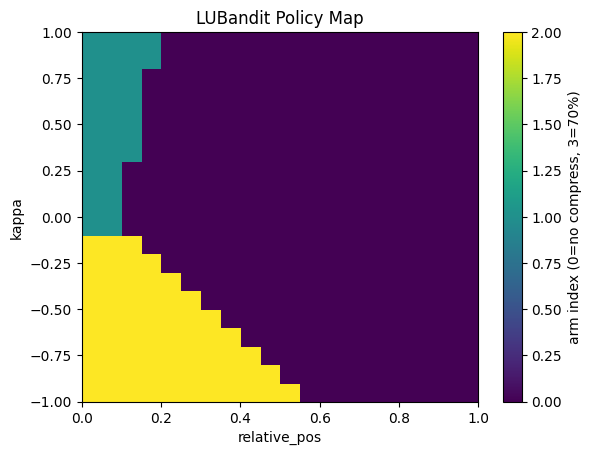

In [12]:
from lu_bandit.analysis import policy_map
import matplotlib.pyplot as plt

grid = policy_map(
    "checkpoints/lu_bandit_math.pkl",
    x_feature="relative_pos",   # x轴: 对话进度
    y_feature="kappa",          # y轴: 时序曲率
)
plt.imshow(grid, origin="lower", cmap="viridis",
           extent=[0, 1, -1, 1], aspect="auto")
plt.colorbar(label="arm index (0=no compress, 3=70%)")
plt.xlabel("relative_pos"); plt.ylabel("kappa")
plt.title("LUBandit Policy Map"); plt.show()


## Comparison: Error Category — Baseline vs Context Compression
对目标错误类别（由 `TARGET_CATEGORY` 配置）跑压缩实验，对比：
1. Accuracy 变化（baseline 0% vs compressed）
2. Temporal curvature κ 曲线形态是否改变
3. 压缩后四种错误 + SUCCESS 的分布变化

**支持类别**: `EVOLVES_STAYS_WRONG` · `SAME_WRONG_DESPITE_HINTS` · `ATTEMPTED_BUT_UNRESOLVED` · `NEVER_ATTEMPTED_ANSWER`

In [9]:
# # ─── Config ────────────────────────────────────────────────────────────────────
# TARGET_CATEGORY = "NEVER_ATTEMPTED_ANSWER"   # 改这里切换类别

# CATEGORY_FILES = {
#     "EVOLVES_STAYS_WRONG": {
#         "file":   "logs/math/sharded-at0-ut0/(40-103ESW)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl",
#         "pt_dir": "logs/hidden_states/math/(40-103ESW)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct",
#     },
#     "SAME_WRONG_DESPITE_HINTS":  {
#         "file":   "logs/math/sharded-at0-ut0/(40-103SWH)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl",
#         "pt_dir": "logs/hidden_states/math/(40-103SWH)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct",
#     },
#     "ATTEMPTED_BUT_UNRESOLVED":  {
#         "file":   "logs/math/sharded-at0-ut0/(40-103ABU)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl",
#         "pt_dir": "logs/hidden_states/math/(40-103ABU)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct",
#     },
#     "NEVER_ATTEMPTED_ANSWER":    {
#         "file":   "logs/math/sharded-at0-ut0/(40-103NAA)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct.jsonl",
#         "pt_dir": "logs/hidden_states/math/(40-103NAA)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct",
#     },
# }
# BASE_PT_DIR = "logs/hidden_states/math/(40-103)sharded-at0-ut0_math_meta-llama_Llama-3.1-8B-Instruct"

# comp_file   = CATEGORY_FILES[TARGET_CATEGORY]["file"]
# comp_pt_dir = CATEGORY_FILES[TARGET_CATEGORY]["pt_dir"]
# assert comp_file and comp_pt_dir, f"No experiment file configured for {TARGET_CATEGORY}"

# # task_ids that belong to TARGET_CATEGORY in the baseline
# target_task_ids = set(
#     df.loc[df["conv_id"].map(cat_map) == TARGET_CATEGORY, "task_id"].dropna()
# )

# # ── Load compressed records (filtered to TARGET_CATEGORY task_ids) ─────────────
# comp_recs = []
# with open(comp_file) as f:
#     for line in f:
#         rec = json.loads(line)
#         if rec.get("task_id") not in target_task_ids:
#             continue
#         rec["category"] = classify_entry_math(rec)
#         rec["turns"]    = count_turns(rec.get("trace", []))
#         comp_recs.append(rec)

# df_comp_raw = pd.DataFrame([{
#     "conv_id":  r["conv_id"],
#     "score":    r.get("score"),
#     "turns":    r["turns"],
#     "category": r["category"],
# } for r in comp_recs])
# df_comp_raw["correct"] = df_comp_raw["score"].eq(1.0)

# comp_correct_map = {r["conv_id"]: r.get("score", 0) == 1.0 for r in comp_recs}
# comp_cat_map_new = {r["conv_id"]: r["category"] for r in comp_recs}

# # ── 1. Accuracy & category breakdown ──────────────────────────────────────────
# base_cat_n   = sum(1 for c in cat_map.values() if c == TARGET_CATEGORY)
# comp_correct = int(df_comp_raw["correct"].sum())
# comp_n       = len(df_comp_raw)

# print(f"Accuracy: {TARGET_CATEGORY} ===")
# print(f"  Baseline  : 0 / {base_cat_n}  =  0.0%")
# print(f"  Compressed: {comp_correct} / {comp_n}  =  {comp_correct/comp_n:.1%}")
# print()
# print("=== Category breakdown after compression ===")
# print(df_comp_raw["category"].value_counts().to_string())

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ax = axes[0]
# heights = [0.0, comp_correct / comp_n]
# bars = ax.bar(["Baseline\n(no compression)", "With\ncompression"],
#               heights, color=["#94a3b8", "#16a34a"], alpha=0.85, width=0.5)
# for bar, v in zip(bars, heights):
#     ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
#             f"{v:.1%}", ha="center", va="bottom", fontsize=12, fontweight="bold")
# ax.set_ylim(0, max(0.5, comp_correct / comp_n + 0.15))
# ax.set_ylabel("Accuracy")
# ax.set_title(f"{TARGET_CATEGORY}\nAccuracy Comparison (n={comp_n})", fontweight="bold")
# ax.grid(alpha=0.2, axis="y")

# ax2 = axes[1]
# cat_order = ["SUCCESS", "EVOLVES_STAYS_WRONG", "SAME_WRONG_DESPITE_HINTS", "ATTEMPTED_BUT_UNRESOLVED"]
# counts = df_comp_raw["category"].value_counts().reindex(cat_order, fill_value=0)
# bottom = 0.0
# for cat in cat_order:
#     v = counts[cat]
#     if v == 0:
#         continue
#     ax2.bar([f"Compressed {TARGET_CATEGORY[:3]}… (n={comp_n})"], [v / comp_n],
#             bottom=[bottom / comp_n],
#             color=COLORS.get(cat, "#888"), alpha=0.85,
#             label=f"{cat} ({v})")
#     bottom += v
# ax2.set_ylim(0, 1.05)
# ax2.set_ylabel("Proportion")
# ax2.set_title("Category Breakdown\nafter Compression", fontweight="bold")
# ax2.legend(fontsize=7, loc="upper right")
# ax2.grid(alpha=0.2, axis="y")

# plt.suptitle(f"Context Compression: Impact on {TARGET_CATEGORY}", fontsize=11, fontweight="bold")
# plt.tight_layout()
# plt.show()

# # ── 2. Load kappa ──────────────────────────────────────────────────────────────
# def load_kappa_rows(pt_dir, conv_ids, correct_map_local, group_label, new_cat_map=None):
#     rows = []
#     for cid in conv_ids:
#         pt = Path(pt_dir) / f"{cid}.pt"
#         if not pt.exists():
#             continue
#         data = torch.load(pt, map_location="cpu", weights_only=False)
#         hs_map = {e["label"]: e["hidden_states"][FOCUS_LAYER].numpy()
#                   for e in data["hidden_states"]}
#         turn_labels = sorted(
#             [k for k in hs_map if k.startswith("turn_")],
#             key=lambda x: int(x.split("_")[1])
#         )
#         all_labels = ["goal"] + turn_labels
#         turns = len(all_labels)
#         if turns not in TARGET_TURNS:
#             continue
#         for i in range(2, turns):
#             tl, tp1, tp2 = all_labels[i], all_labels[i-1], all_labels[i-2]
#             kappa = cosine(hs_map[tl] - hs_map[tp1], hs_map[tp1] - hs_map[tp2])
#             rows.append({
#                 "conv_id":      cid,
#                 "turns":        turns,
#                 "turn_idx":     int(tl.split("_")[1]),
#                 "kappa":        kappa,
#                 "correct":      bool(correct_map_local.get(cid, False)),
#                 "group":        group_label,
#                 "new_category": (new_cat_map or {}).get(cid, group_label),
#             })
#     return pd.DataFrame(rows)

# base_correct_map_local = dict(zip(df["conv_id"], df["score"].eq(1)))
# base_cat_cids = [cid for cid, cat in cat_map.items() if cat == TARGET_CATEGORY]
# success_cids  = [cid for cid, cat in cat_map.items() if cat == "SUCCESS"]

# df_base_cat  = load_kappa_rows(BASE_PT_DIR, base_cat_cids,
#                                 base_correct_map_local, f"Baseline {TARGET_CATEGORY}")
# df_comp_cat  = load_kappa_rows(comp_pt_dir, list(comp_correct_map.keys()),
#                                 comp_correct_map, f"Compressed {TARGET_CATEGORY}", comp_cat_map_new)
# df_success_k = load_kappa_rows(BASE_PT_DIR, success_cids, base_correct_map_local, "SUCCESS")

# print(f"\nKappa rows — Baseline {TARGET_CATEGORY}: {len(df_base_cat)},  "
#       f"Compressed: {len(df_comp_cat)},  SUCCESS: {len(df_success_k)}")

# # ── 3. Overall curvature comparison ───────────────────────────────────────────
# def mean_curve(df_subset):
#     rows = []
#     for ti, g in df_subset[df_subset["turns"].isin(TARGET_TURNS)].groupby("turn_idx"):
#         vals = g["kappa"].dropna().values
#         if len(vals) < 2:
#             continue
#         mean = vals.mean()
#         ci   = scipy_stats.sem(vals) * scipy_stats.t.ppf(0.9, df=len(vals) - 1)
#         rows.append({"turn_idx": ti, "mean": mean, "ci": ci, "n": len(vals)})
#     return pd.DataFrame(rows).sort_values("turn_idx")

# curves = {
#     "Baseline SUCCESS":              (mean_curve(df_success_k), COLORS["SUCCESS"],                   "o-",  2.0),
#     f"Baseline {TARGET_CATEGORY}":   (mean_curve(df_base_cat),  COLORS.get(TARGET_CATEGORY, "#888"), "^--", 2.0),
#     f"Compressed {TARGET_CATEGORY}": (mean_curve(df_comp_cat),  "#16a34a",                           "s-",  2.0),
# }

# fig, ax = plt.subplots(figsize=(9, 5))
# for label, (curve, color, ls, lw) in curves.items():
#     if curve.empty:
#         continue
#     ax.plot(curve["turn_idx"], curve["mean"], ls, color=color, lw=lw, ms=4, label=label)
#     ax.fill_between(curve["turn_idx"],
#                     curve["mean"] - curve["ci"],
#                     curve["mean"] + curve["ci"],
#                     color=color, alpha=0.12)
# ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.35)
# ax.set_xlabel("Turn index")
# ax.set_ylabel("Mean κ (temporal curvature)")
# ax.set_ylim(-0.6, 0.12)
# ax.set_title(f"Temporal Curvature: Baseline vs Compressed {TARGET_CATEGORY}\n(turns 3–8 pooled, 90% CI)",
#              fontweight="bold")
# ax.legend()
# ax.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# # ── 4. Compressed split by new outcome ────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(9, 5))
# ax.plot(mean_curve(df_success_k)["turn_idx"], mean_curve(df_success_k)["mean"],
#         "o-",  color=COLORS["SUCCESS"],                   lw=2, ms=4, label="Baseline SUCCESS")
# ax.plot(mean_curve(df_base_cat)["turn_idx"],  mean_curve(df_base_cat)["mean"],
#         "^--", color=COLORS.get(TARGET_CATEGORY, "#888"), lw=2, ms=4, label=f"Baseline {TARGET_CATEGORY}")

# for outcome, color, ls in [
#     ("SUCCESS",       "#16a34a",                           "s-"),
#     (TARGET_CATEGORY, COLORS.get(TARGET_CATEGORY, "#888"), "D:"),
# ]:
#     sub = df_comp_cat[df_comp_cat["new_category"] == outcome]
#     n   = sub["conv_id"].nunique()
#     if sub.empty or n < 2:
#         continue
#     c = mean_curve(sub)
#     if c.empty:
#         continue
#     ax.plot(c["turn_idx"], c["mean"], ls, color=color, lw=1.8, ms=4,
#             label=f"Compressed → {outcome} (n={n})")
#     ax.fill_between(c["turn_idx"], c["mean"] - c["ci"], c["mean"] + c["ci"],
#                     color=color, alpha=0.12)

# ax.axhline(0, color="k", lw=0.6, ls="--", alpha=0.35)
# ax.set_xlabel("Turn index")
# ax.set_ylabel("Mean κ")
# ax.set_ylim(-0.6, 0.12)
# ax.set_title(f"Temporal Curvature: Compressed {TARGET_CATEGORY} split by new outcome",
#              fontweight="bold")
# ax.legend(fontsize=8)
# ax.grid(alpha=0.2)
# plt.tight_layout()
# plt.show()

# # ── 5. Per-conv mean kappa summary ────────────────────────────────────────────
# for label, df_g in [(f"Baseline {TARGET_CATEGORY}", df_base_cat),
#                     (f"Compressed {TARGET_CATEGORY}", df_comp_cat)]:
#     vals = df_g.groupby("conv_id")["kappa"].mean().dropna().values
#     print(f"{label:35s}  mean κ = {vals.mean():.4f}  ±{vals.std():.4f}  (n={len(vals)})")